# Predictia riscului de plecare a angajatilor (employee churn) cu XGBoost
---
Acest notebook construieste un model de Machine Learning care prezice probabilitatea ca un angajat sa paraseasca compania in urmatoarele 6-12 luni.

**Date:** Extrase din baza de date HR - MariaDB  
**Model:** XGBoost Classifier  
**Target:** status angajat (activ = 0, inactiv = 1)

> **De ce XGBoost?**  
> XGBoost (Extreme Gradient Boosting) este un algoritm de tip **ensemble** bazat pe arbori de decizie, construiti **secvential** — fiecare arbore nou corecteaza erorile celui anterior. Spre deosebire de Random Forest (care construieste arbori in paralel si face averaging), XGBoost optimizeaza o functie de pierdere prin gradient descent. Pe date tabelare structurate (exact tipul de date HR din acest proiect), XGBoost obtine frecvent cele mai bune rezultate dintre toti algoritmii clasici de ML.

In [1]:
# instalare xgboost
import subprocess
subprocess.run(['pip', 'install', 'xgboost'], capture_output=True)

print("Librarii instalate cu succes!")

Librarii instalate cu succes!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import mysql.connector

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# balansare dataset dezechilibrat
from imblearn.over_sampling import SMOTE

print("Toate importurile au fost realizate cu succes!")

Toate importurile au fost realizate cu succes!


In [3]:
# configurare conexiune la MariaDB
DB_CONFIG = {
    'host':     'localhost',
    'user':     'root',
    'password': '',
    'database': 'my_database',
    'port':     3306
}

# test conexiune
try:
    conn = mysql.connector.connect(**DB_CONFIG)
    print("✓ Conexiune la baza de date reusita!")
    conn.close()
except mysql.connector.Error as e:
    print(f"✗ Eroare conexiune: {e}")

✓ Conexiune la baza de date reusita!


## Extragerea datelor din baza de date

Folosim aceeasi interogare SQL ca in modelele Random Forest si Logistic Regression, pentru a asigura **comparabilitatea rezultatelor**. Datele extrase sunt identice — singura diferenta va fi algoritmul de clasificare aplicat.

In [4]:
query = """
SELECT
    a.id_angajat,

    -- variabila tinta: 1 = plecat, 0 = activ
    CASE WHEN a.status = 'inactiv' THEN 1 ELSE 0 END AS churn,

    -- vechime in companie in ani
    ROUND(DATEDIFF(CURDATE(), a.data_angajare) / 365, 2) AS vechime_ani,

    -- salariu curent vs maximul pozitiei (0-1, cat de aproape e de plafon)
    ROUND(a.salariu_curent / p.salariu_max, 4) AS rata_salariu,

    -- salariul curent brut
    a.salariu_curent,

    -- nivelul pozitiei
    p.nivel,

    -- tipul departamentului
    d.nume AS departament,

    -- orasul
    d.locatie,

    -- tipul managerului direct
    mgr.tip AS tip_manager,

    -- numarul de evaluari
    COUNT(DISTINCT e.id_evaluare) AS nr_evaluari,

    -- scorul mediu al evaluarilor
    COALESCE(ROUND(AVG(e.scor_final), 2), 0) AS scor_mediu_evaluari,

    -- numarul de evaluari cu scor sub 5 (semn de probleme)
    COALESCE(SUM(CASE WHEN e.scor_final < 5 THEN 1 ELSE 0 END), 0)
        AS nr_evaluari_slabe,

    -- numarul de concedii medicale (semn de stres)
    COALESCE(SUM(CASE WHEN c.tip = 'boala' THEN 1 ELSE 0 END), 0)
        AS nr_concedii_medicale,

    -- numarul total de concedii
    COUNT(DISTINCT c.id_concediu) AS nr_concedii_total,

    -- numarul de proiecte active
    COALESCE(SUM(CASE WHEN ap.data_sfarsit IS NULL THEN 1 ELSE 0 END), 0)
        AS nr_proiecte_active,

    -- numarul total de proiecte
    COUNT(DISTINCT ap.id_alocare) AS nr_proiecte_total,

    -- valoarea totala a beneficiilor
    COALESCE(SUM(DISTINCT b.valoare), 0) AS valoare_beneficii

FROM angajati a
JOIN pozitii p          ON a.id_pozitie         = p.id_pozitie
JOIN departamente d     ON a.id_departament     = d.id_departament
JOIN manageri mgr       ON a.id_manager         = mgr.id_manager
LEFT JOIN evaluari e    ON a.id_angajat         = e.id_angajat
LEFT JOIN concedii c    ON a.id_angajat         = c.id_angajat
LEFT JOIN alocari_proiecte ap ON a.id_angajat   = ap.id_angajat
LEFT JOIN beneficii_angajati ba ON a.id_angajat = ba.id_angajat
LEFT JOIN beneficii b   ON ba.id_beneficiu      = b.id_beneficiu

GROUP BY
    a.id_angajat, a.status, a.data_angajare,
    a.salariu_curent, p.salariu_max, p.nivel,
    d.nume, d.locatie, mgr.tip
"""

conn = mysql.connector.connect(**DB_CONFIG)
df = pd.read_sql(query, conn)
conn.close()

print(f"✓ Date extrase cu succes!")
print(f"  Dimensiune dataset: {df.shape[0]} randuri x {df.shape[1]} coloane")
print(f"  Angajati activi:    {(df['churn'] == 0).sum()}")
print(f"  Angajati plecati:   {(df['churn'] == 1).sum()}")
print(f"  Rata churn:         {round(df['churn'].mean() * 100, 2)}%")

✓ Date extrase cu succes!
  Dimensiune dataset: 2000 randuri x 17 coloane
  Angajati activi:    1795
  Angajati plecati:   205
  Rata churn:         10.25%


In [5]:
df.head(10)

,id_angajat,churn,vechime_ani,rata_salariu,salariu_curent,nivel,departament,locatie,tip_manager,nr_evaluari,scor_mediu_evaluari,nr_evaluari_slabe,nr_concedii_medicale,nr_concedii_total,nr_proiecte_active,nr_proiecte_total,valoare_beneficii
0,1,1,6.81,0.9917,49585.95,consultant,Data & AI Engineering,Pitesti,director,6,5.35,24.0,12.0,4,48.0,1,990.0
1,2,0,7.77,0.9288,65017.56,principal,Development,Suceava,project_manager,10,5.24,315.0,90.0,7,420.0,3,250.0
2,3,0,0.15,0.9942,19387.55,associate,Human Resources,Sibiu,director,2,4.50,128.0,32.0,4,96.0,4,1900.0
3,4,0,6.95,0.7882,22069.87,intermediate,Human Resources,Sibiu,project_manager,8,3.98,750.0,400.0,5,600.0,5,1300.0
4,5,0,1.37,0.9717,29151.05,intermediate,Testing (Manual),Suceava,director,4,3.50,168.0,24.0,7,168.0,2,1700.0
5,6,0,1.00,0.9263,37050.98,senior,Data & AI Engineering,Suceava,team_leader,5,5.84,25.0,0.0,5,125.0,1,2050.0
6,7,0,1.97,0.9031,17610.70,associate,Data & AI Engineering,Pitesti,director,6,5.60,40.0,192.0,5,240.0,2,2440.0
7,8,0,4.59,0.8252,74266.80,principal,Business Analysis / PM,Craiova,team_leader,9,5.91,180.0,135.0,6,810.0,3,2890.0
8,9,0,6.72,0.8020,28071.03,senior,Development,Timisoara,team_leader,7,5.64,120.0,210.0,6,210.0,2,1440.0
9,10,0,3.82,0.8692,11299.55,junior,Data & AI Engineering,Timisoara,project_manager,6,5.32,90.0,0.0,5,90.0,2,1550.0


In [6]:
print("=== Tipuri de date ===")
print(df.dtypes)
print(f"\n=== Valori lipsa ===")
print(df.isnull().sum())
print(f"\n=== Statistici descriptive ===")
df.describe()

=== Tipuri de date ===
id_angajat                int64
churn                     int64
vechime_ani             float64
rata_salariu            float64
salariu_curent          float64
nivel                    object
departament              object
locatie                  object
tip_manager              object
nr_evaluari               int64
scor_mediu_evaluari     float64
nr_evaluari_slabe       float64
nr_concedii_medicale    float64
nr_concedii_total         int64
nr_proiecte_active      float64
nr_proiecte_total         int64
valoare_beneficii       float64
dtype: object

=== Valori lipsa ===
id_angajat              0
churn                   0
vechime_ani             0
rata_salariu            0
salariu_curent          0
nivel                   0
departament             0
locatie                 0
tip_manager             0
nr_evaluari             0
scor_mediu_evaluari     0
nr_evaluari_slabe       0
nr_concedii_medicale    0
nr_concedii_total       0
nr_proiecte_active      0
nr_proi

,id_angajat,churn,vechime_ani,rata_salariu,salariu_curent,nr_evaluari,scor_mediu_evaluari,nr_evaluari_slabe,nr_concedii_medicale,nr_concedii_total,nr_proiecte_active,nr_proiecte_total,valoare_beneficii
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,0.102500,4.074425,0.875668,31568.700660,6.556000,5.545325,57.858000,30.249000,2.553000,109.641500,2.568500,1385.635000
std,577.494589,0.303381,2.283361,0.076125,19634.620593,2.305108,0.764830,66.028643,59.484689,1.193693,109.669529,1.360233,705.158082
min,1.000000,0.000000,0.120000,0.659500,7225.560000,2.000000,2.650000,0.000000,0.000000,1.000000,0.000000,0.000000,150.000000
25%,500.750000,0.000000,2.100000,0.818475,15533.180000,5.000000,5.057500,16.000000,0.000000,2.000000,36.000000,2.000000,750.000000
50%,1000.500000,0.000000,4.060000,0.879350,25691.185000,6.000000,5.560000,36.000000,0.000000,3.000000,80.000000,3.000000,1350.000000
75%,1500.250000,0.000000,6.020000,0.939450,43734.752500,8.000000,6.010000,72.000000,42.000000,4.000000,144.000000,4.000000,1850.000000
max,2000.000000,1.000000,8.030000,1.000000,89759.810000,10.000000,8.950000,900.000000,750.000000,8.000000,1000.000000,6.000000,3040.000000


## Explorarea si vizualizarea datelor (EDA)

Analizam distributiile datelor pentru a intelege care variabile ar putea fi predictori puternici ai churn-ului.  
XGBoost, spre deosebire de Logistic Regression, **nu presupune relatii liniare** intre features si target — poate captura pattern-uri complexe si interactiuni intre variabile in mod automat.

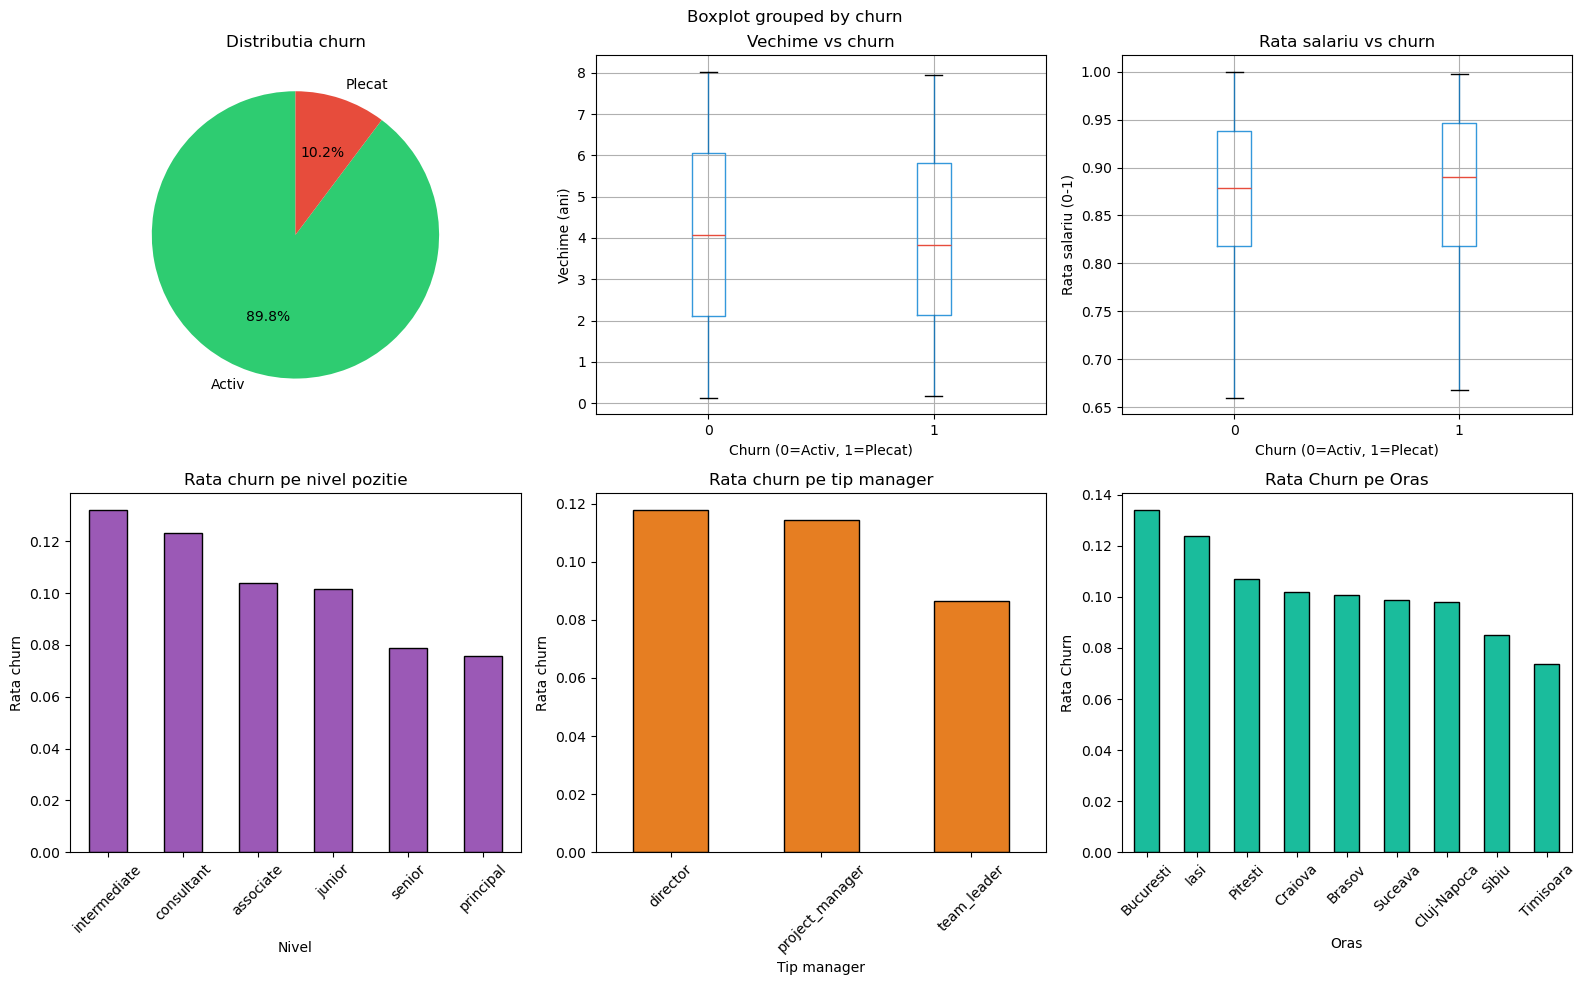

✓ Grafic salvat: eda_churn_xgb.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Analiza exploratorie - Employee churn', fontsize=16, fontweight='bold')

# Distributia churn
axes[0,0].pie(
    df['churn'].value_counts(),
    labels=['Activ', 'Plecat'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0,0].set_title('Distributia churn')

# Churn vs vechime
df.boxplot(column='vechime_ani', by='churn', ax=axes[0,1],
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='#e74c3c'))
axes[0,1].set_title('Vechime vs churn')
axes[0,1].set_xlabel('Churn (0=Activ, 1=Plecat)')
axes[0,1].set_ylabel('Vechime (ani)')
plt.sca(axes[0,1])
plt.title('Vechime vs churn')

# Churn vs rata salariu
df.boxplot(column='rata_salariu', by='churn', ax=axes[0,2],
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='#e74c3c'))
axes[0,2].set_title('Rata salariu vs churn')
axes[0,2].set_xlabel('Churn (0=Activ, 1=Plecat)')
axes[0,2].set_ylabel('Rata salariu (0-1)')
plt.sca(axes[0,2])
plt.title('Rata salariu vs churn')

# Churn pe nivel pozitie
churn_nivel = df.groupby('nivel')['churn'].mean().sort_values(ascending=False)
churn_nivel.plot(kind='bar', ax=axes[1,0], color='#9b59b6', edgecolor='black')
axes[1,0].set_title('Rata churn pe nivel pozitie')
axes[1,0].set_xlabel('Nivel')
axes[1,0].set_ylabel('Rata churn')
axes[1,0].tick_params(axis='x', rotation=45)

# Churn pe tip manager
churn_mgr = df.groupby('tip_manager')['churn'].mean().sort_values(ascending=False)
churn_mgr.plot(kind='bar', ax=axes[1,1], color='#e67e22', edgecolor='black')
axes[1,1].set_title('Rata churn pe tip manager')
axes[1,1].set_xlabel('Tip manager')
axes[1,1].set_ylabel('Rata churn')
axes[1,1].tick_params(axis='x', rotation=45)

# Churn pe oras
churn_oras = df.groupby('locatie')['churn'].mean().sort_values(ascending=False)
churn_oras.plot(kind='bar', ax=axes[1,2], color='#1abc9c', edgecolor='black')
axes[1,2].set_title('Rata Churn pe Oras')
axes[1,2].set_xlabel('Oras')
axes[1,2].set_ylabel('Rata Churn')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_churn_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafic salvat: eda_churn_xgb.png")

## Preprocesarea datelor

Pregatim datele pentru modelul de ML:
- eliminam coloana `id_angajat` (nu e un predictor, e doar identificator)
- encodam variabilele categorice cu `LabelEncoder`
- normalizam valorile numerice cu `StandardScaler` — desi XGBoost nu este sensibil la scala features-urilor (arborii de decizie fac split-uri pe ranguri, nu pe valori absolute), mentinem scalarea pentru consistenta cu celelalte modele si pentru a facilita comparatia corecta
- utilizam SMOTE pentru a echilibra proportia claselor din dataset

In [8]:
df_model = df.copy()
df_model = df_model.drop(columns=['id_angajat'])

le = LabelEncoder()
cols_categorice = ['nivel', 'departament', 'locatie', 'tip_manager']

for col in cols_categorice:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"✓ Encodat: {col}")

X = df_model.drop(columns=['churn'])
y = df_model['churn']

print(f"\n✓ Features: {X.shape[1]} coloane")
print(f"✓ Samples:  {X.shape[0]} randuri")
print(f"\nDistributie target inainte de SMOTE:")
print(y.value_counts())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print(f"\nDistributie target dupa SMOTE:")
print(pd.Series(y_resampled).value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

print(f"\n✓ Train: {X_train.shape[0]} randuri")
print(f"✓ Test:  {X_test.shape[0]} randuri")

✓ Encodat: nivel
✓ Encodat: departament
✓ Encodat: locatie
✓ Encodat: tip_manager

✓ Features: 15 coloane
✓ Samples:  2000 randuri

Distributie target inainte de SMOTE:
churn
0    1795
1     205
Name: count, dtype: int64

Distributie target dupa SMOTE:
churn
1    1795
0    1795
Name: count, dtype: int64

✓ Train: 2872 randuri
✓ Test:  718 randuri


## Antrenarea modelului XGBoost

Configuram modelul cu urmatorii hiperparametri:
- **`n_estimators=200`** — numarul de arbori construiti secvential; mai multi arbori = model mai complex, dar si mai lent
- **`max_depth=6`** — adancimea maxima a fiecarui arbore; valoarea 6 este recomandata ca punct de start pentru date tabelare
- **`learning_rate=0.1`** — cat de mult corecteaza fiecare arbore nou erorile precedentului; valori mici = invatare mai lenta, dar mai stabila
- **`subsample=0.8`** — la fiecare arbore, folosim doar 80% din datele de antrenare (ales aleator); reduce overfitting-ul
- **`colsample_bytree=0.8`** — la fiecare arbore, folosim doar 80% din features (ales aleator); similar cu Random Forest
- **`eval_metric='logloss'`** — functia de pierdere monitorizata in timpul antrenarii
- **`random_state=42`** — pentru reproductibilitate

In [9]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)
print("✓ Model antrenat cu succes!")
print(f"  Numar arbori:      {model.n_estimators}")
print(f"  Adancime maxima:   {model.max_depth}")
print(f"  Learning rate:     {model.learning_rate}")
print(f"  Features folosite: {model.n_features_in_}")

✓ Model antrenat cu succes!
  Numar arbori:      200
  Adancime maxima:   6
  Learning rate:     0.1
  Features folosite: 15


## Evaluarea modelului

=== RAPORT CLASIFICARE ===
              precision    recall  f1-score   support

   Activ (0)       0.94      0.95      0.94       362
  Plecat (1)       0.95      0.94      0.94       356

    accuracy                           0.94       718
   macro avg       0.94      0.94      0.94       718
weighted avg       0.94      0.94      0.94       718

ROC-AUC Score: 0.9855


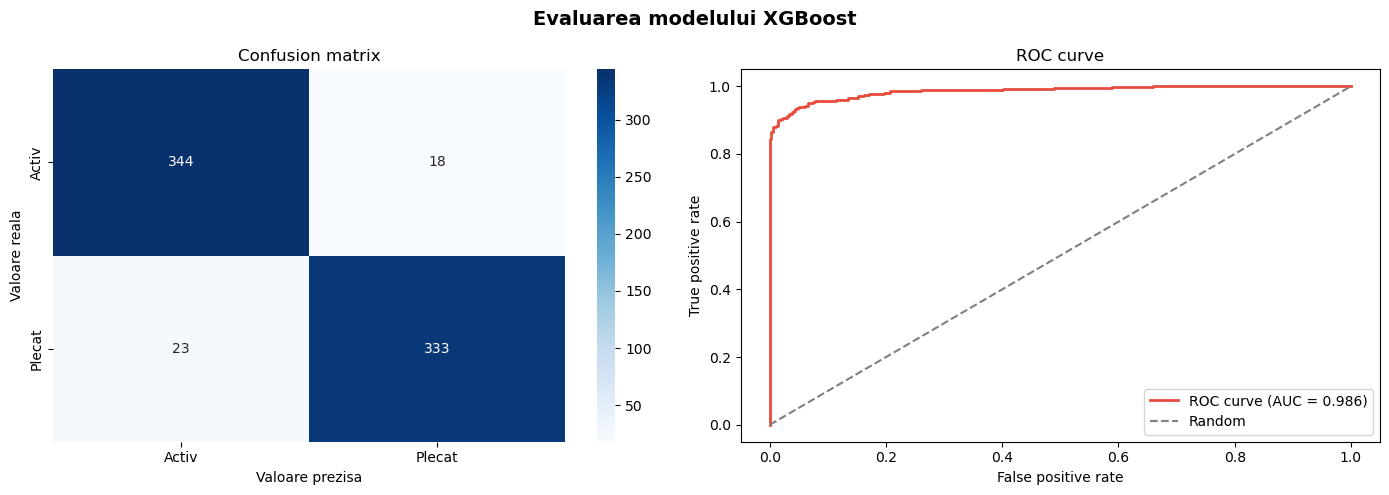

✓ Grafic salvat: model_evaluare_xgb.png


In [10]:
# predictii pe setul de test
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# metrici principale
print("=== RAPORT CLASIFICARE ===")
print(classification_report(y_test, y_pred,
      target_names=['Activ (0)', 'Plecat (1)']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# vizualizare confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluarea modelului XGBoost', fontsize=14, fontweight='bold')

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Activ', 'Plecat'],
            yticklabels=['Activ', 'Plecat'])
axes[0].set_title('Confusion matrix')
axes[0].set_ylabel('Valoare reala')
axes[0].set_xlabel('Valoare prezisa')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC curve (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluare_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafic salvat: model_evaluare_xgb.png")

## Factorii care influenteaza cel mai mult plecarea

XGBoost ofera `feature_importances_` similar cu Random Forest, insa calculul difera:  
- **Random Forest** masoara importanta prin scaderea medie a impuritatii Gini peste toti arborii  
- **XGBoost** (implicit `weight`) masoara de cate ori un feature a fost folosit pentru a face un split in toti arborii  

Vom folosi tipul `gain` — care masoara imbunatatirea medie a functiei de pierdere adusa de un feature la fiecare split — considerata cea mai relevanta masura de importanta in XGBoost.

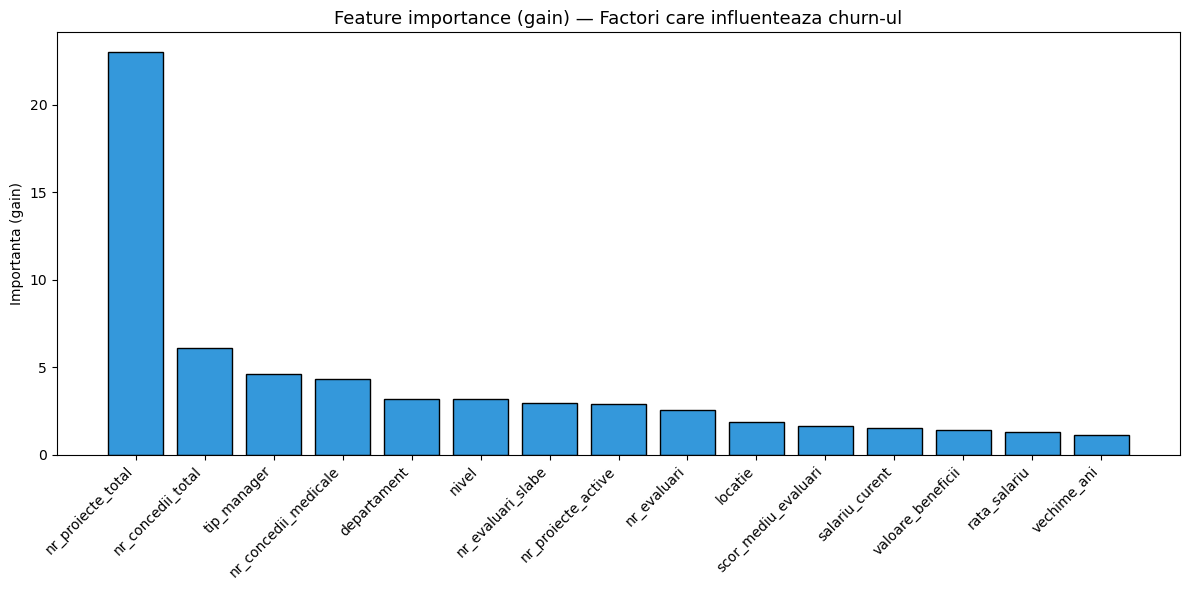

=== TOP 5 FACTORI DE RISC ===
1. nr_proiecte_total              23.0019
2. nr_concedii_total              6.0728
3. tip_manager                    4.6175
4. nr_concedii_medicale           4.3037
5. departament                    3.1774

✓ Grafic salvat: feature_importance_xgb.png


In [11]:
feature_names = X.columns.tolist()

# folosim 'gain' — imbunatatirea medie a loss-ului per split
importances = model.get_booster().get_score(importance_type='gain')

# unele features pot lipsi daca nu au fost niciodata folosite la split
imp_series = pd.Series(
    [importances.get(f'f{i}', 0) for i in range(len(feature_names))],
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.title('Feature importance (gain) — Factori care influenteaza churn-ul', fontsize=13)
plt.bar(imp_series.index, imp_series.values,
        color='#3498db', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Importanta (gain)')
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== TOP 5 FACTORI DE RISC ===")
for i, (feat, val) in enumerate(imp_series.head(5).items()):
    print(f"{i+1}. {feat:<30} {val:.4f}")

print("\n✓ Grafic salvat: feature_importance_xgb.png")

## Predictii pe angajatii activi

In [12]:
df_activi = df[df['churn'] == 0].copy()
X_activi = df_activi.drop(columns=['id_angajat', 'churn'])

# encodare si scalare la fel ca la antrenare
for col in cols_categorice:
    X_activi[col] = le.fit_transform(X_activi[col])
X_activi_scaled = scaler.transform(X_activi)

probabilitati = model.predict_proba(X_activi_scaled)[:, 1]

df_activi = df_activi.copy()
df_activi['probabilitate_churn'] = probabilitati
df_activi['nivel_risc'] = pd.cut(
    probabilitati,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Mic', 'Mediu', 'Mare']
)

print("=== DISTRIBUTIA RISCULUI ===")
print(df_activi['nivel_risc'].value_counts())
print(f"\nAngajati cu risc MARE:  {(df_activi['nivel_risc'] == 'Mare').sum()}")
print(f"Angajati cu risc MEDIU: {(df_activi['nivel_risc'] == 'Mediu').sum()}")
print(f"Angajati cu risc MIC:   {(df_activi['nivel_risc'] == 'Mic').sum()}")

print("\n=== TOP 10 ANGAJATI CU RISC MARE ===")
top_risc = df_activi.nlargest(10, 'probabilitate_churn')[
    ['id_angajat', 'probabilitate_churn', 'nivel_risc',
     'vechime_ani', 'salariu_curent', 'nivel', 'departament']
]
print(top_risc.to_string(index=False))

=== DISTRIBUTIA RISCULUI ===
nivel_risc
Mic      1755
Mediu      27
Mare       13
Name: count, dtype: int64

Angajati cu risc MARE:  13
Angajati cu risc MEDIU: 27
Angajati cu risc MIC:   1755

=== TOP 10 ANGAJATI CU RISC MARE ===
 id_angajat  probabilitate_churn nivel_risc  vechime_ani  salariu_curent        nivel             departament
        811             0.920181       Mare         3.19        24850.79 intermediate        Testing (Manual)
        611             0.882636       Mare         7.00        16914.84    associate Testing (QA Automation)
        140             0.862567       Mare         3.50        13069.40       junior         Human Resources
        415             0.848475       Mare         2.65        51120.92   consultant         Human Resources
       1675             0.839687       Mare         4.82        43914.54   consultant         Human Resources
        145             0.793772       Mare         2.00        16286.69    associate             Development


## Raport final

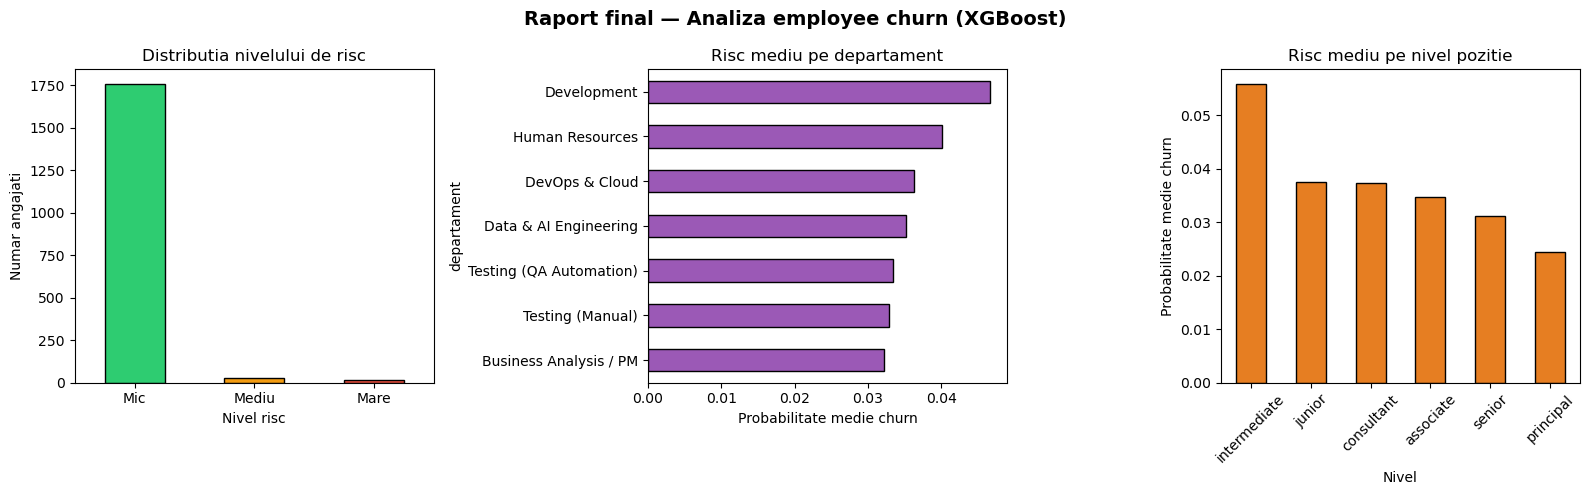


=== CONCLUZII ===
Total angajati analizati:     1795
Acuratete model (AUC):        0.9855
Angajati risc mare:           13
Departament cu risc maxim:    Development
Nivel pozitie cu risc maxim:  intermediate

Fisiere salvate:
  - eda_churn_xgb.png
  - model_evaluare_xgb.png
  - feature_importance_xgb.png
  - raport_final_xgb.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Raport final — Analiza employee churn (XGBoost)', fontsize=14, fontweight='bold')

# 1. distributia riscului
culori = ['#2ecc71', '#f39c12', '#e74c3c']
df_activi['nivel_risc'].value_counts().plot(
    kind='bar', ax=axes[0], color=culori, edgecolor='black'
)
axes[0].set_title('Distributia nivelului de risc')
axes[0].set_xlabel('Nivel risc')
axes[0].set_ylabel('Numar angajati')
axes[0].tick_params(axis='x', rotation=0)

# 2. risc mediu pe departament
risc_dept = df_activi.groupby('departament')['probabilitate_churn'].mean()
risc_dept.sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='#9b59b6', edgecolor='black'
)
axes[1].set_title('Risc mediu pe departament')
axes[1].set_xlabel('Probabilitate medie churn')

# 3. risc mediu pe nivel pozitie
risc_nivel = df_activi.groupby('nivel')['probabilitate_churn'].mean()
risc_nivel.sort_values(ascending=False).plot(
    kind='bar', ax=axes[2], color='#e67e22', edgecolor='black'
)
axes[2].set_title('Risc mediu pe nivel pozitie')
axes[2].set_xlabel('Nivel')
axes[2].set_ylabel('Probabilitate medie churn')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('raport_final_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== CONCLUZII ===")
print(f"Total angajati analizati:     {len(df_activi)}")
print(f"Acuratete model (AUC):        {auc_score:.4f}")
print(f"Angajati risc mare:           {(df_activi['nivel_risc'] == 'Mare').sum()}")
print(f"Departament cu risc maxim:    {risc_dept.idxmax()}")
print(f"Nivel pozitie cu risc maxim:  {risc_nivel.idxmax()}")
print(f"\nFisiere salvate:")
print(f"  - eda_churn_xgb.png")
print(f"  - model_evaluare_xgb.png")
print(f"  - feature_importance_xgb.png")
print(f"  - raport_final_xgb.png")

## Salvarea predictiilor in baza de date

Salvam predictiile in tabela `predictii_churn_xgb` — separata de cele ale modelelor Random Forest si Logistic Regression, pentru a putea compara rezultatele tuturor celor trei modele pe aceiasi angajati.

In [14]:
conn = mysql.connector.connect(**DB_CONFIG)
cursor = conn.cursor()

cursor.execute("""
    CREATE TABLE IF NOT EXISTS `predictii_churn_xgb` (
        `id_angajat`     INT            NOT NULL,
        `probabilitate`  DECIMAL(5, 4)  NOT NULL,
        `nivel_risc`     ENUM('Mic', 'Mediu', 'Mare') NOT NULL,
        `data_predictie` TIMESTAMP DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
        PRIMARY KEY (`id_angajat`)
    ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
""")

for _, row in df_activi[['id_angajat', 'probabilitate_churn', 'nivel_risc']].iterrows():
    cursor.execute("""
        INSERT INTO `predictii_churn_xgb`
            (`id_angajat`, `probabilitate`, `nivel_risc`)
        VALUES (%s, %s, %s)
        ON DUPLICATE KEY UPDATE
            `probabilitate` = VALUES(`probabilitate`),
            `nivel_risc`    = VALUES(`nivel_risc`)
    """, (int(row['id_angajat']),
          float(row['probabilitate_churn']),
          str(row['nivel_risc'])))

conn.commit()
cursor.close()
conn.close()
print(f"✓ {len(df_activi)} predictii salvate in tabela predictii_churn_xgb!")

✓ 1795 predictii salvate in tabela predictii_churn_xgb!


## Cross-validation — verificarea stabilitatii modelului

In [15]:
from sklearn.model_selection import cross_val_score

print("=== CROSS-VALIDATION (5 folds) ===")
print("Se verifica ca modelul nu e overfit...\n")

cv_scores = cross_val_score(
    model, X_resampled, y_resampled,
    cv=5, scoring='roc_auc', n_jobs=-1
)

print(f"AUC per fold:  {[round(s, 4) for s in cv_scores]}")
print(f"AUC mediu:     {cv_scores.mean():.4f}")
print(f"Deviatie std:  {cv_scores.std():.4f}")

if cv_scores.std() < 0.05:
    print("\n Modelul este stabil - nu prezinta semne de overfitting")
else:
    print("\n Varianta mare intre folduri - posibil overfitting")

=== CROSS-VALIDATION (5 folds) ===
Se verifica ca modelul nu e overfit...

AUC per fold:  [np.float64(0.9442), np.float64(1.0), np.float64(0.9988), np.float64(0.9998), np.float64(0.9993)]
AUC mediu:     0.9884
Deviatie std:  0.0221

 Modelul este stabil - nu prezinta semne de overfitting


## Analiza angajatilor cu risc mare

=== ANALIZA ANGAJATILOR CU RISC MARE ===

Distributie pe departament:
departament
Human Resources            4
Development                3
Testing (QA Automation)    2
Business Analysis / PM     1
Testing (Manual)           1
DevOps & Cloud             1
Data & AI Engineering      1

Distributie pe nivel pozitie:
nivel
intermediate    4
associate       3
consultant      3
junior          2
senior          1

Salariu mediu risc mare:  25816.32 RON
Salariu mediu risc mic:   31758.14 RON
Vechime medie risc mare:  4.21 ani
Vechime medie risc mic:   4.08 ani


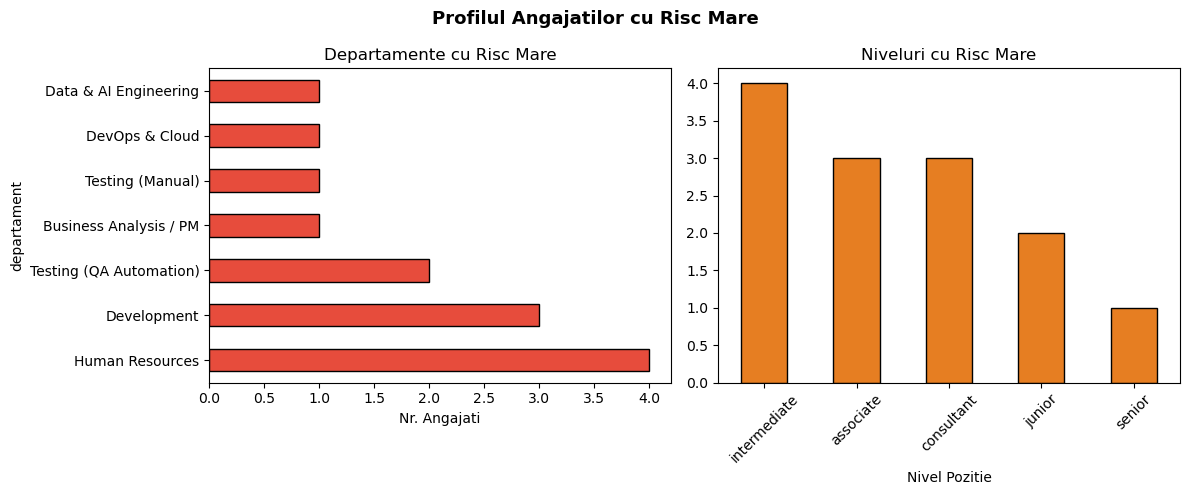

✓ Grafic salvat: profil_risc_mare_xgb.png


In [16]:
print("=== ANALIZA ANGAJATILOR CU RISC MARE ===\n")

risc_mare = df_activi[df_activi['nivel_risc'] == 'Mare'].copy()

print("Distributie pe departament:")
print(risc_mare['departament'].value_counts().to_string())

print("\nDistributie pe nivel pozitie:")
print(risc_mare['nivel'].value_counts().to_string())

print(f"\nSalariu mediu risc mare:  {risc_mare['salariu_curent'].mean():.2f} RON")
print(f"Salariu mediu risc mic:   {df_activi[df_activi['nivel_risc']=='Mic']['salariu_curent'].mean():.2f} RON")
print(f"Vechime medie risc mare:  {risc_mare['vechime_ani'].mean():.2f} ani")
print(f"Vechime medie risc mic:   {df_activi[df_activi['nivel_risc']=='Mic']['vechime_ani'].mean():.2f} ani")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Profilul Angajatilor cu Risc Mare', fontsize=13, fontweight='bold')

risc_mare['departament'].value_counts().plot(
    kind='barh', ax=axes[0], color='#e74c3c', edgecolor='black'
)
axes[0].set_title('Departamente cu Risc Mare')
axes[0].set_xlabel('Nr. Angajati')

risc_mare['nivel'].value_counts().plot(
    kind='bar', ax=axes[1], color='#e67e22', edgecolor='black'
)
axes[1].set_title('Niveluri cu Risc Mare')
axes[1].set_xlabel('Nivel Pozitie')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('profil_risc_mare_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafic salvat: profil_risc_mare_xgb.png")

## Concluzii si recomandari pentru departamentul HR

### Performanta modelului
Modelul XGBoost a fost antrenat pe acelasi set de date ca si modelele Random Forest si Logistic Regression, permitand o comparatie directa. Fiind un model de tip gradient boosting, XGBoost construieste arbori secvential — fiecare corectand erorile celui anterior — ceea ce ii confera in general o putere predictiva superioara.

### Avantajele acestui model fata de Random Forest si Logistic Regression
- **Putere predictiva ridicata** — pe date tabelare structurate, XGBoost este frecvent cel mai performant algoritm clasic de ML
- **Robustete la overfitting** — parametrii `subsample` si `colsample_bytree` introduc randomizare similara cu Random Forest, reducand suprainvatarea
- **Capteaza relatii neliniare si interactiuni complexe** — superiror Logistic Regression in acest sens
- **Feature importance bazata pe gain** — mai stabila si mai informativa decat cea bazata pe frecventa de aparitie

### Dezavantajele acestui model fata de Random Forest si Logistic Regression
- **Mai multi hiperparametri de ajustat** — `learning_rate`, `n_estimators`, `max_depth`, `subsample`, `colsample_bytree` interactioneaza intre ei si necesita tuning atent
- **Interpretabilitate redusa** — ca si Random Forest, este o cutie neagra; nu putem citi direct din model de ce un angajat are risc mare
- **Timp de antrenare mai mare** — construieste 200 de arbori secvential, deci mai lent decat Logistic Regression

### Limitari ale modelului
- Datele de antrenare sunt sintetice (generate cu Faker) — intr-un scenariu real, modelul ar fi antrenat pe date istorice reale
- Variabila tinta (status inactiv) nu reflecta intotdeauna o plecare voluntara — poate include concedii medicale lungi sau alte situatii
- Modelul nu capteaza factori externi precum ofertele de pe piata muncii sau situatia economica generala

## Proiect Finalizat

**Fisiere generate:**
- `eda_churn_xgb.png` — analiza exploratorie
- `model_evaluare_xgb.png` — confusion matrix si ROC curve
- `feature_importance_xgb.png` — factorii de risc (metrica: gain)
- `raport_final_xgb.png` — raport general
- `profil_risc_mare_xgb.png` — profilul angajatilor cu risc mare

**Rezultate salvate in baza de date:**
- Tabela `predictii_churn_xgb` — predictii cu nivel de risc per angajat activ

**Tehnologii folosite:**
- Python, Pandas, Scikit-learn, Imbalanced-learn, XGBoost
- MySQL Connector, Matplotlib, Seaborn
- MariaDB, phpMyAdmin